## 1. Intro to Causality

### Why is ML bad

- ML works until it doesn't (data drifts, relationships change etc)

- ML has difficulties inferring causality
    - In the hotel industry, prices are low outside the tourist season, and prices are high when demand is highest and hotels are full. Given that data, a naive prediction might suggest that increasing the price would lead to more rooms sold.

### When is correlation causation?

- Correlation != Causation
- Example:
    - Claim: Schools that give tablets to their students perform better than those that don’t
    - Counter: Schools with tablets are wealthier, so students would do better than average even without the tablets
    - Conclusion: We can’t conclude that giving tablets to kids during classes will cause an increase in their academic performance, but we can only say that tablets in school are associated with high academic performance

- Let's generate a dataset to look into this
    - Note that the marginal effect of a tablet on ENEM score is **actually negative** (-50) !!! So the tablet worsens the score
    - But the effect from tuition_fee is marginally positive at 0.7. 
    - So if you're richer, you do better academically. And if you're richer, you are more likely to get a tablet.


In [2]:
import pandas as pd
import numpy as np
from scipy.special import expit,logit
import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib import style
import math
np.random.seed(123)

In [3]:
def get_dataset():
    ## Sample size
    n = 100 

    ##Generate tuition fee as random normal distribution
    tuition_fee = np.random.normal(1000, 300, n).round() 

    ## The probability of getting a tablet is given by the expit(...) function above for each individual student as a function deviation from tuition fee mean. So the more you pay for tuition fee, the high the probability of getting a tablet
    tablet = np.random.binomial(1, (expit((tuition_fee - tuition_fee.mean()) / tuition_fee.std()))**2).astype(bool) 

    ## Let the "academic performance" be measured by ENEM score, which is normally distributed with the following mean and stddev. 
    enem_score = np.random.normal(200 - 50 * tablet + 0.7 * tuition_fee, 200)

    ## For ease of visualisation, minmax scale the ENEM score to [0, 1000]
    enem_score = (enem_score - enem_score.min()) / enem_score.max()
    enem_score *= 1000

    data = pd.DataFrame(dict(enem_score=enem_score, Tuition=tuition_fee, Tablet=tablet))    
    return data
data = get_dataset()

In [4]:
# plt.figure(figsize=(6,8));
# sns.boxplot(y="enem_score", x="Tablet", data=data).set_title('ENEM score by Tablet in Class');
# plt.show();

#### Jargon

- **Treatment** Let treatment for observation $i$ be $T_i$ where: $T_i = \left \{ 
    \begin{matrix} 
        1 & \text{if unit i received treatment} \\
        0 & \text{otherwise} \\
    \end{matrix} 
\right.$

- **Outcome** Let the outcome for observation $i$ be $Y_i$

- The **fundamental problem for causal inference** is this:
    - We either know $Y_i | T_i = 0$ or $Y_i | T_i = 1$, but never both. (i.e. you can't both treat and not treat a person)

- Therefore, we need to talk in terms of **potential outcomes**
    - Let $Y_{0,i}$ be the outcome for observation $i$ without the treatment
    - Let $Y_{1,i}$ be the outcome for observation $i$ with the treatment

- The purpose of any causal analysis is to measure the **individual treatment effect (ITE)**
    - $\text{TE}_i = Y_{1,i} - Y_{0,i}$

- If we average all our ITEs, this becomes the **Average Treatment Effect (ATE)**
    - $\text{ATE} = \frac{\sum{\text{TE}_i}}{n} = E[Y_{1,i} - Y_{0,i}]$

- Usually, **ATE** is not measurable by definition, due to **fundamental problem of causal inference** 
    - i.e. Because there isn't really a way to both expose and not expose an observation to a treatment at the same time. So $E[Y_{1,i} - Y_{0,i}]$ is not measurable

- Instead, we measure **Average Treatment on Treated (ATT)**
    - $\text{ATT} = E[Y_1 - Y_0 | T = 1]$

- The code block below will illustrate the concepts here. Let's assume we're god, and we know what happens for both $Y0$ and $Y1$

In [10]:
data = pd.DataFrame({
    'i': [1,2,3,4],
    'Y0': [500,600,700,800],
    'Y1': [450,600,600,750],
    'T': [0,0,1,1],
    'Y': [500,600,600,750],
})

data['treatment_effect'] = data['Y1'] - data['Y0']
average_treatment_effect = float(np.mean(data['treatment_effect']))
average_treatment_on_treated = float(np.mean(data.loc[data['T'] == 1]['treatment_effect']))

display(data)
print(f"{average_treatment_effect=}")
print(f"{average_treatment_on_treated=}")

,i,Y0,Y1,T,Y,treatment_effect
0,1,500,450,0,500,-50
1,2,600,600,0,600,0
2,3,700,600,1,600,-100
3,4,800,750,1,750,-50


average_treatment_effect=-50.0
average_treatment_on_treated=-75.0


- However, in reality, we never have this sort of dataset (i.e. we never know both the effect when T=1 and T=0). So this is more realistic data:

- Note: The treatment effect is **NOT** $\frac{600+750}{2} - \frac{500+600}{2} = 125$
    - Notice how different this is from the true ATE above!!

In [12]:
data = pd.DataFrame({
    'i': [1,2,3,4],
    'Y0': [500,600,np.nan,np.nan,],
    'Y1': [np.nan,np.nan,600,750],
    'T': [0,0,1,1],
    'Y': [500,600,600,750],
})

data['treatment_effect'] = data['Y1'] - data['Y0'] ## This is None!
biased_treatment_effect = float(data.loc[data['T'] == 1, 'Y'].mean() - data.loc[data['T'] == 0, 'Y'].mean())

display(data)
print(f"{biased_treatment_effect=}")
print(f"{average_treatment_effect=}")

,i,Y0,Y1,T,Y,treatment_effect
0,1,500.0,NaN,0,500,NaN
1,2,600.0,NaN,0,600,NaN
2,3,NaN,600.0,1,600,NaN
3,4,NaN,750.0,1,750,NaN


biased_treatment_effect=125.0
average_treatment_effect=-50.0


#### Bias

- Why is the biased treatment effect so different from the true ATE when the data is missing? This is **Bias** in estimating treatment effects
    - This is because, in the second case, we compute $E[Y|T=1] - E[Y|T=0]$. That is, the difference between the outcomes for the treated group and the untreated group.
    - But causal impact is $E[Y_1 - Y_0]$. That is, the difference between the treated group

- So why is $E[Y|T=1] - E[Y|T=0]$ biased? Let's see where the bias comes from:
$$\begin{aligned}
    E[Y|T=1] - E[Y|T=0] &= E[Y_1|T=1] - E[Y_0|T=0] & \text{Population difference in expectation between treated and untreated outcomes} \\
    &= E[Y_1|T=1] - E[Y_0|T=0] + E[Y_0|T=1] - E[Y_0|T=1] & \text{Adding and subtracting the same term} \\
    &= (E[Y_1|T=1] - E[Y_0|T=1]) + (E[Y_0|T=1] - E[Y_0|T=0]) \\
    &= E[Y_1 - Y_0 | T=1] + (E[Y_0|T=1] - E[Y_0|T=0]) \\
\end{aligned}$$

- $E[Y_1 - Y_0 | T=1]$ measures the **Average Treatment on Treated**
- $E[Y_0|T=1] - E[Y_0|T=0]$ measures the selection bias; that is, the difference in the non-treatment outcomes between those in the treatment group and control group
    - i.e. how the treated and control group differ before the treatment, in case neither of them has received the treatment

#### So when does correlation = causation?

- From the math above, Correlation = Causation when: $E[Y_0 | T=1] = E[Y_0 | T=0]$ because the bias term disappears. 
$$\begin{aligned}
    E[Y_1 - Y_0 | T = 1] &= E[Y_1 | T=1] - E[Y_0 | T=1] \\
    &= E[Y_1 | T=1] - E[Y_0 | T = 1] & \text{because } E[Y_0 | T=1] = E[Y_0 | T=0] \\
    &= E[Y | T=1] - E[Y | T = 0] & \text{causal effect!}
\end{aligned}$$

- In the case where $E[Y_0 | T=1] = E[Y_0 | T=0]$ (i.e. no difference in the no-treatment-outcome between treatment and control), you might also want to check that $E[Y_1 | T=1] = E[Y_1 | T=0]$ (i.e. no difference in the treatment-outcome between treatment and control)

- If this is true, then $E[Y_1 - Y_0 | T=1] = E[Y_1 - Y_0 | T=0]$
 
- In this case, $E[Y|T=1] - E[Y|T=0] = \text{ATT} = \text{ATE}$

### Pictorial Representation of Bias

- Let's go back to the original dataset to see where the bias comes from
- From the scatter plot below, it's clear that higher tuition fees correlates with higher test scores
- At the same time, higher tuition fees also correlates with incidence of Tablet!!!
- This leads to a confounding bias, where the association between higher tuition fees and higher test scores may be due to the association between higher tuition fees OR the higher incidence of tablets

<Axes: xlabel='Tuition', ylabel='enem_score'>

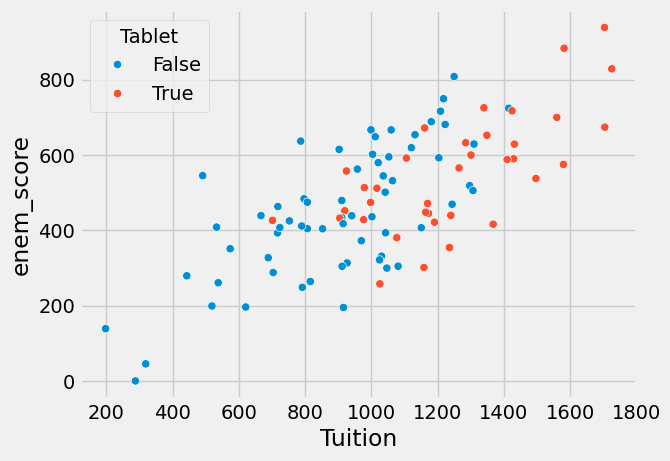

In [92]:
data = get_dataset()
sns.scatterplot(x=data['Tuition'], y=data['enem_score'], hue=data['Tablet'])

## Side Notes

- You'll notice that there is an `expit` and `logit` function used in the example above. These are defined as:
$$\begin{aligned}
    \text{expit} = \frac{1}{(1 + e^{-x})} \\ \\

    \text{logit} = \ln(\frac{p}{1-p}) \\ \\
\end{aligned}$$

- Notice that $\text{logit}(\text{expit}(x)) = x$
$$\begin{aligned}
    \text{logit}(\text{expit}(x)) &= \ln({\frac{\frac{1}{(1 + e^{-x})}}{1 - \frac{1}{(1 + e^{-x})}}}) \\
    &= \ln({\frac{\frac{1}{(1 + e^{-x})}}{\frac{e^{-x}}{(1 + e^{-x})}}}) \\
    &= \ln({\frac{1}{e^{-x}}}) \\
    &= \ln(e^{x}) \\
    &= x
\end{aligned}$$